# Title: "Modeling via unit-Fréchet distribution"

# Auxiliar functions

In [1]:
### ---------------------------------------------
### Probability density function of the unit Frechet distribution
### ---------------------------------------------
#par: (sigma, alpha, rho), s.t. sigma>0, alpha>0 and 0<=rho<=1
#w: data (values in (0,1))
duf<- function(par,w){
  s1=par[1]#sigma
  a=par[2]#alpha
  rho=par[3]#rho
  
  s=(w/(1-w))
  
  c1=a/(s1^a)* (s^{a-1})* ((s+1)^2)
  c2=2*((((s^a)/(s1^a))+1)^2) - rho*(((s^a)/(s1^a))^2 +1)
  d1=((((s^a)/(s1^a)+1)^2) -rho*(s^a)/(s1^a)  )^2
  d2=(((s^a)/(s1^a))+1)^2
  
  out=c1*((c2/d1)-1/d2)
  return(out)
}

### ---------------------------------------------
### CDF of the unit Frechet
### ---------------------------------------------
#par: (sigma, alpha, rho), s.t. sigma>0, alpha>0 and 0<=rho<=1
#w: data (values in (0,1))
puf<- function(par, x){
  w=x
  
  s1=par[1]#sigma
  a=par[2]#alpha
  rho=par[3]#rho
  
  s=(w/(1-w))
  
  c1=(s^a)/(s1^a)
  c2=((((s^a)/(s1^a))+1)^2)-rho 
  d1=((((s^a)/(s1^a)+1)^2) -rho*(s^a)/(s1^a)  )
  d2=(((s^a)/(s1^a))+1)
  
  out=c1*c2/(d1*d2)
  
  out=ifelse(w<=0, 0, ifelse(w>=1,1, out))
  return(out)
  
}


### ---------------------------------------------
### Information criteria
### ---------------------------------------------
#ll_max: maximum log-likelihood
#n_par: number of parameters to be estimated
#n: sample size
aic<-function(ll_max, n_par){-2*ll_max+2*n_par}
bic<-function(ll_max, n_par,n){-2*ll_max+n_par*log(n) }

### ---------------------------------------------
### Fit of the unit Frechet distribution
### ---------------------------------------------
if (!requireNamespace("AdequacyModel", quietly = TRUE)) {
  install.packages("AdequacyModel")
}
library(AdequacyModel)
fit_uf3=function(w, start_values=c(1,1,0), lim_inf= c(0,0,0), lim_sup=c(10,10,1)){
  result_1 = suppressMessages(suppressWarnings(goodness.fit(pdf = duf, cdf = puf,
                          starts = start_values, data = w, method = "PSO",
                          domain = c(0,1),mle = NULL, lim_inf =lim_inf,
                          lim_sup = lim_sup, S = 250, prop=0.1, N=50)))
  return(list(par=result_1$mle, llf_max=-result_1$Value, 
              AIC=aic(-result_1$Value, 3),
              BIC=bic(-result_1$Value, 3, length(w))))
}

# Fiting medium pass completion proportion (X) with the unit-Fréchet distribution

In [3]:
data=c(0.289, 0.700, 0.211, 0.733,0.444, 0.544, 0.089, 0.767, 0.433, 0.911, 0.800, 0.733,
    0.278, 0.456, 0.178, 0.200, 0.244, 0.467, 0.022, 0.400,0.378, 0.589, 0.600, 0.567,
    0.844, 0.711, 0.289, 0.178, 0.489, 0.278, 0.611, 0.544, 0.267, 0.489, 0.467,0.300, 
    0.311)

(tab=summary(data))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0220  0.2780  0.4560  0.4544  0.6000  0.9110 

In [4]:
set.seed(1)
(x_fit=fit_uf3(data))

$par
[1] 0.8064094 1.0589749 0.8234969

$llf_max
[1] 4.920844

$AIC
[1] -3.841687

$BIC
[1] 0.9910666

In [5]:
#Kolmogorov-Smirnov test
suppressMessages(suppressWarnings(ks.test(data, puf, par=x_fit$par)))


	One-sample Kolmogorov-Smirnov test

data:  data
D = 0.096146, p-value = 0.8837
alternative hypothesis: two-sided


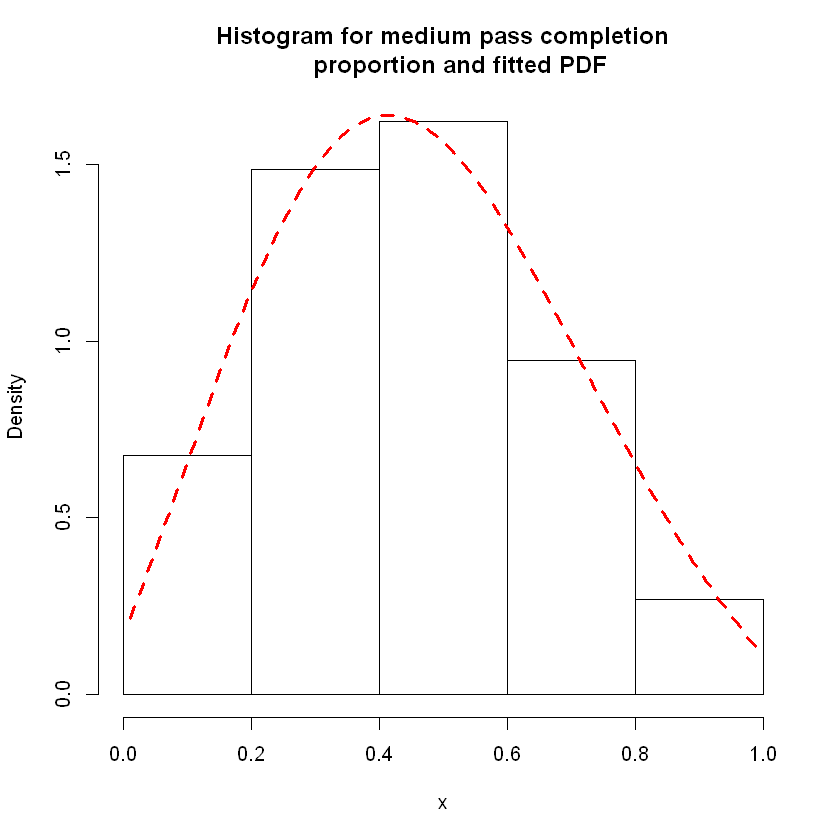

In [6]:
xpoints=seq(0,1,length.out=100)[-c(1,100)]
g_uf=duf(x_fit$par,xpoints)

hist(data, breaks = 5, probability = T, main="Histogram for medium pass completion
     proportion and fitted PDF", xlab = "x")
lines(xpoints, g_uf, type="l", 
      pch=16, 
      lty=2, 
      lwd=3.0,
      col="red") 

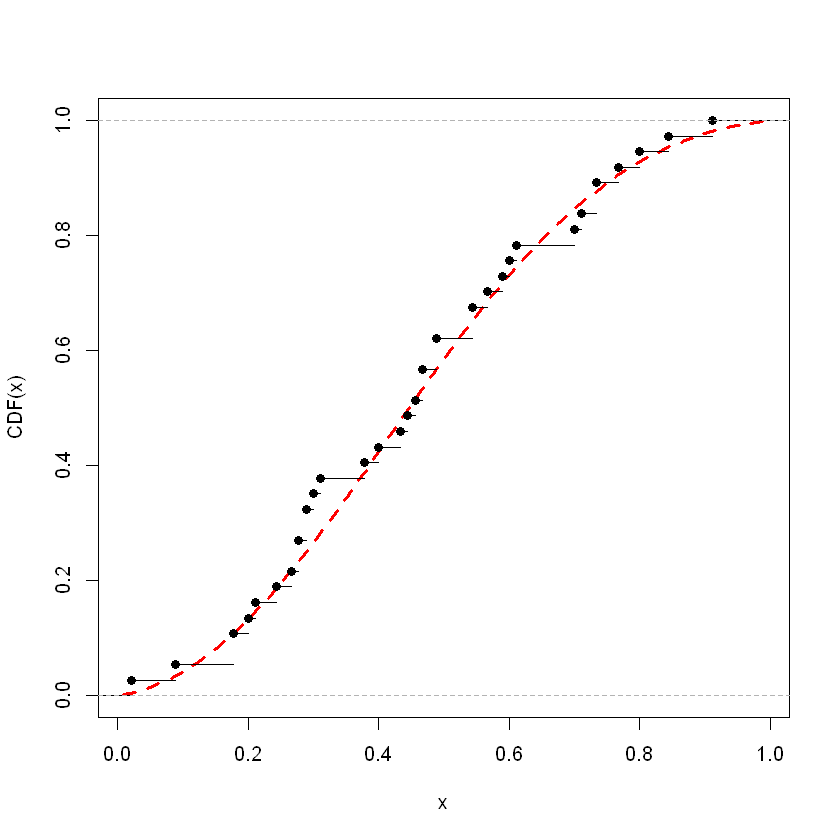

In [7]:
x_cdf_uf=puf(x_fit$par,xpoints)

plot(xpoints, x_cdf_uf, type="l", main="",
     xlab = "x", ylab = "CDF(x)", pch=16, 
      lty=2, lwd=3.0, col="red")
lines(ecdf(data), pch=16, lty=1, col="black") 

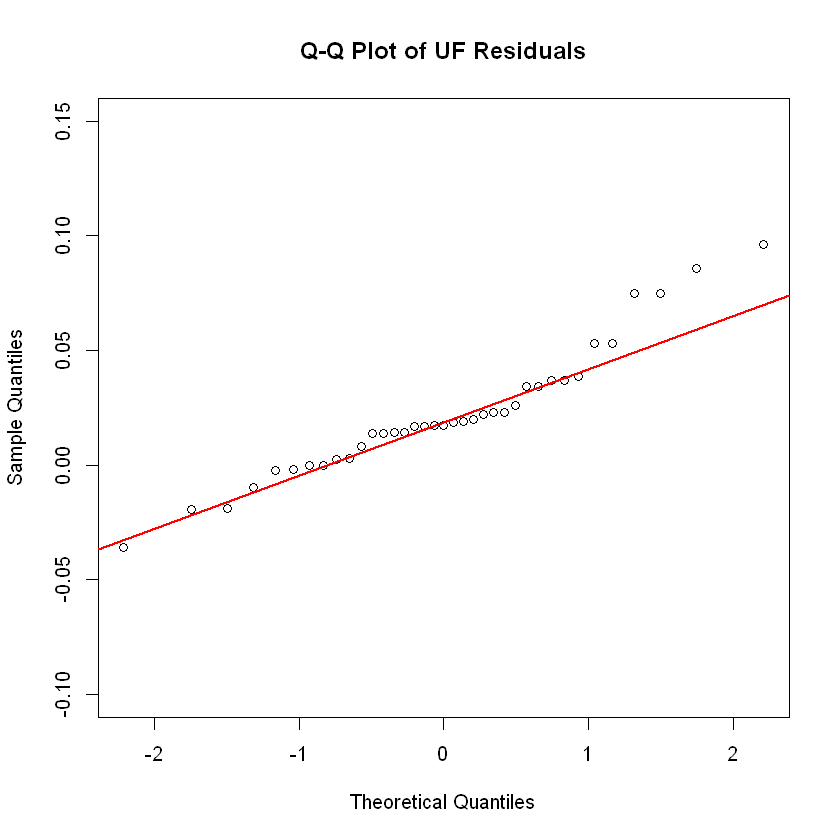

In [8]:
# Empirical CDF
ecdf_func <- ecdf(data)  # Empirical CDF function
empirical_cdf <- ecdf_func(data)  # Values of the empirical CDF at data points

# UF
theoretical_cdf <- puf(x_fit$par, data)  # Values of the theoretical CDF at data points
residuals <- empirical_cdf - theoretical_cdf

qqnorm(residuals, main = "Q-Q Plot of UF Residuals", ylim=c(-0.1,0.15))
qqline(residuals, col = "red", lwd = 2)

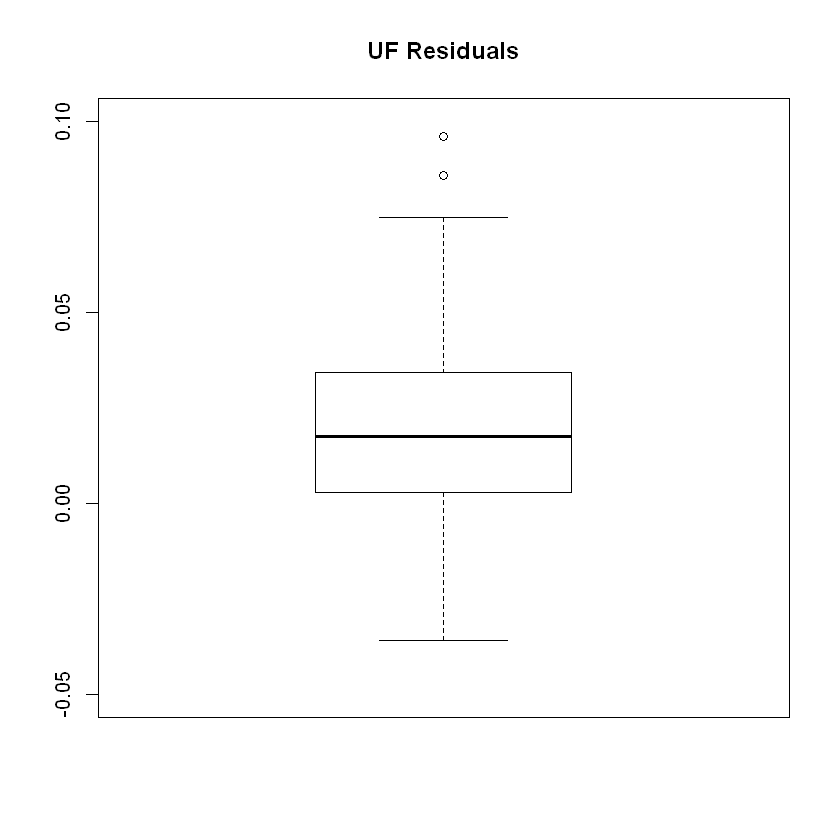

In [9]:
boxplot(residuals, ylim=c(-0.05,0.1), main="UF Residuals")